## Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install "transformers<4.40"

In [ ]:


import numpy as np
import pandas as pd
import torch
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import re

In [ ]:
from huggingface_hub import login
login()

## Config

In [ ]:
PATH = "/content/drive/MyDrive/work/chromatin modification prediction" # @param {type:"string", value:"/content/drive/MyDrive/work/chromatin modification prediction"}
TRAIN_CSV = "data.csv" # @param {type:"string", value:"data.csv"}
TRAIN_LABELS = "labels.csv" # @param {type:"string", value:"labels.csv"}

MINIHACK = True # @param {type:"boolean"}
TEST_CSV = "testsequences.csv" # @param {type:"string", value:"testsequences.csv"}
TEST_LABELS = "val_ref.csv" # @param {type:"string", value:"val_ref.csv"}


LEARNING_RATE = 0.0001 # @param {type:"number", value:0.0001}
EPOCHS = 1 # @param {type:"integer", value:1}
BATCH_SIZE = 64 # @param {type:"integer", value:256}

LAYERS_TO_FREEZE = 16 # @param {type:"integer"}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data

In [ ]:
train, labels = pd.read_csv(os.path.join(PATH,TRAIN_CSV), header=None), pd.read_csv(os.path.join(PATH,TRAIN_LABELS), dtype=np.int64, header=None)
data_df = pd.concat([train, labels], axis=1)
data_df.columns = ["seq", "label"]

# Ensure 'seq' column is string type and replace common non-standard missing values
data_df['seq'] = data_df['seq'].astype(str).replace({'': np.nan, 'nan': np.nan})

data_df = data_df.dropna()

## Dataset Class

The label is converted to be 0 indexed.

In [ ]:
class ChromatinDataset(torch.utils.data.Dataset):
    def __init__(self, df, oversample=True, limit_oversample=9):
        self.df = df
        self.value_counts = self.df['label'].value_counts()
        self.oversampled_counts = None
        if oversample:
            max_size = self.df['label'].value_counts().max()
            print(f"Max size: {max_size}")
            print(self.df['label'].value_counts())
            lst = [self.df]
            for class_index, group in self.df.groupby('label'):
                if len(group) < max_size:
                    # Sample with replacement to match the majority class size
                    lst.append(group.sample(min(max_size - len(group), len(group) * limit_oversample), replace=True))
            self.df = pd.concat(lst)
            # Shuffle the dataset so batches are mixed
            self.df = self.df.sample(frac=1).reset_index(drop=True)

            print(f"Oversampling complete. New dataset size: {len(self.df)}")
            print(self.df['label'].value_counts())
            self.oversampled_counts = self.df['label'].value_counts()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        sequence = row["seq"]
        label = row["label"] - 1

        return sequence, label

In [ ]:

data_df = data_df.dropna()
X_train, X_test, y_train, y_test = train_test_split(data_df["seq"], data_df["label"], test_size=0.2, random_state=42)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

train_df = pd.concat([X_train, y_train], axis=1)
train_data = ChromatinDataset(train_df, oversample=True, limit_oversample=3)
test_df = pd.concat([X_test, y_test], axis=1)
test_data = ChromatinDataset(test_df, oversample=False)


Max size: 56307
label
18    56307
6      7789
5      5101
17     4306
11     1952
13     1354
9       699
16      505
7       499
1       301
10      295
12      265
3       162
4       122
14      113
8       103
2        86
15       41
Name: count, dtype: int64
Oversampling complete. New dataset size: 151079
label
18    56307
6     31156
5     20404
17    17224
11     7808
13     5416
9      2796
16     2020
7      1996
1      1204
10     1180
12     1060
3       648
4       488
14      452
8       412
2       344
15      164
Name: count, dtype: int64


## Model

In [ ]:
model_name = "InstaDeepAI/nucleotide-transformer-2.5b-multi-species"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=18,
    trust_remote_code=True,
    output_attentions=True
)

# Convert the model to bfloat16 after loading
model = model.to(torch.bfloat16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-2.5b-multi-species and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
for i,(name, param) in enumerate(model.named_parameters()):
    tokenized_name = name.split('.')
    patt = r"\d+"
    num = re.findall(patt, name)
    # print(num)
    if len(num) > 0:
        layer = int(num[0])
    else:
        continue
    # print(f"{i}: {name}, Layer: {layer}")
    if layer >= LAYERS_TO_FREEZE:
        break
    if not name.startswith("classifier"):
        print(f"freezing params in {name}")
        param.requires_grad = False


freezing params in esm.encoder.layer.0.attention.self.query.weight
freezing params in esm.encoder.layer.0.attention.self.query.bias
freezing params in esm.encoder.layer.0.attention.self.key.weight
freezing params in esm.encoder.layer.0.attention.self.key.bias
freezing params in esm.encoder.layer.0.attention.self.value.weight
freezing params in esm.encoder.layer.0.attention.self.value.bias
freezing params in esm.encoder.layer.0.attention.output.dense.weight
freezing params in esm.encoder.layer.0.attention.output.dense.bias
freezing params in esm.encoder.layer.0.attention.LayerNorm.weight
freezing params in esm.encoder.layer.0.attention.LayerNorm.bias
freezing params in esm.encoder.layer.0.intermediate.dense.weight
freezing params in esm.encoder.layer.0.intermediate.dense.bias
freezing params in esm.encoder.layer.0.output.dense.weight
freezing params in esm.encoder.layer.0.output.dense.bias
freezing params in esm.encoder.layer.0.LayerNorm.weight
freezing params in esm.encoder.layer.0.Lay

## Training

In [ ]:
def train_model(model, train_data, class_weights=None):

    loss_history = []
    model.to(DEVICE)
    dataloader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    if class_weights is not None:
        criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
        print(f"Loading Class Weights: {class_weights}")
    else:
        criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        model.train()
        accumulated_loss = 0.0
        for i,batch in enumerate(dataloader,1):

            sequences, labels = batch

            tokens = tokenizer(sequences, padding=True, truncation=True, return_tensors="pt")
            tokens = {k: v.to(DEVICE) for k, v in tokens.items()}

            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(**tokens, labels=labels)
            loss = outputs.loss

            loss.backward()
            optimizer.step()
            loss_history.append(loss.item())
            accumulated_loss += loss.item()
            if i % 10 == 0:
                print(f"Epoch {epoch+1}/{EPOCHS}, Batch {i}/{len(dataloader)}, Loss: {accumulated_loss/10}")
                accumulated_loss = 0.0


        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item()}")
        torch.save(model.state_dict(), os.path.join(PATH, "model.pt"))
    return loss_history

if train_data.oversampled_counts is not None:
    real = sorted(list(zip(train_data.oversampled_counts.index,train_data.oversampled_counts.values)))
    print(real)
    class_counts = torch.tensor([x[1] for x in real])
    class_weights = 1/class_counts / torch.sum(1/class_counts)
    print(class_weights)
    loss_history = train_model(model, train_data, class_weights)

[(1, np.int64(1204)), (2, np.int64(344)), (3, np.int64(648)), (4, np.int64(488)), (5, np.int64(20404)), (6, np.int64(31156)), (7, np.int64(1996)), (8, np.int64(412)), (9, np.int64(2796)), (10, np.int64(1180)), (11, np.int64(7808)), (12, np.int64(1060)), (13, np.int64(5416)), (14, np.int64(452)), (15, np.int64(164)), (16, np.int64(2020)), (17, np.int64(17224)), (18, np.int64(56307))]
tensor([0.0383, 0.1341, 0.0712, 0.0945, 0.0023, 0.0015, 0.0231, 0.1119, 0.0165,
        0.0391, 0.0059, 0.0435, 0.0085, 0.1020, 0.2812, 0.0228, 0.0027, 0.0008])
Loading Class Weights: tensor([0.0383, 0.1341, 0.0712, 0.0945, 0.0023, 0.0015, 0.0231, 0.1119, 0.0165,
        0.0391, 0.0059, 0.0435, 0.0085, 0.1020, 0.2812, 0.0228, 0.0027, 0.0008])
Epoch 1/1, Batch 10/2361, Loss: 2.065625
Epoch 1/1, Batch 20/2361, Loss: 1.96640625
Epoch 1/1, Batch 30/2361, Loss: 1.95625
Epoch 1/1, Batch 40/2361, Loss: 1.88828125
Epoch 1/1, Batch 50/2361, Loss: 1.78828125
Epoch 1/1, Batch 60/2361, Loss: 1.89921875
Epoch 1/1, Batch

## Evaluation

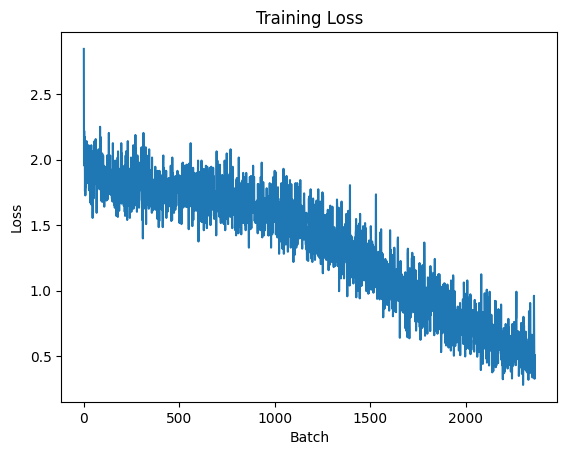

In [ ]:

plt.plot(loss_history)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


## Load Trained Model

In [ ]:

saved_path = os.path.join(PATH, "model.pt")
model.load_state_dict(torch.load(saved_path))


<All keys matched successfully>

In [ ]:
# Enable output_attentions in the model configuration
model.config.output_attentions = True
model.config.output_hidden_states = True

In [ ]:

def test_model(model, test_data):
    test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

    examples = 2
    break_early = False
    attention_for_correct_example = []
    attention_for_incorrect_example = []

    # Accuracy
    model.eval()
    model.to(DEVICE)
    correct = 0
    total = 0

    class_corrects = [0] * 18
    class_totals = [0] * 18

    print("Starting batched evaluation...")
    with torch.no_grad():
        for i, batch in enumerate(test_dataloader):
            sequences, labels = batch

            # Tokenize the batch
            tokens = tokenizer(list(sequences), padding=True, truncation=True, return_tensors="pt")
            print(f"token size: {tokens["input_ids"].shape}")

            tokens = {k: v.to(DEVICE) for k, v in tokens.items()}
            labels = labels.to(DEVICE)

            outputs = model(**tokens)
            print(outputs.attentions[-1].shape)
            _, predicted = torch.max(outputs.logits, 1)

            for j in range(len(labels)):
                if len(attention_for_incorrect_example) >= examples:
                    break
                if predicted[j].item() == labels[j].item():
                    attention_for_correct_example.append(outputs.attentions[-1][j])

            for j in range(len(labels)):
                if len(attention_for_incorrect_example) >= examples:
                    break
                if predicted[j].item() != labels[j].item():
                    attention_for_incorrect_example.append(outputs.attentions[-1][j])


            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            for j in range(len(labels)):
                class_totals[labels[j].item()] += 1
                if predicted[j].item() == labels[j].item():
                    class_corrects[labels[j].item()] += 1

            if break_early and len(attention_for_correct_example) >= examples and len(attention_for_incorrect_example) >= examples:
                break

            balanced_accuracy = 0.0
            seen_classes = 0
            for j in range(18):
                if class_totals[j] > 0:
                    balanced_accuracy += class_corrects[j] / class_totals[j]
                    seen_classes += 1
            balanced_accuracy /= seen_classes
            print(f"Batch {i + 1}/{len(test_dataloader)}, Cumulative Accuracy: {correct/total:.4f}, Balanced Accuracy: {balanced_accuracy}")

    accuracy = correct / total
    print(f"Final Accuracy: {accuracy:.4f}")

    # balanced accuracy
    balanced_accuracy = 0.0
    seen_classes = 0
    for i in range(18):
        if class_totals[i] > 0:
            balanced_accuracy += class_corrects[i] / class_totals[i]
            seen_classes += 1
    balanced_accuracy /= seen_classes
    print(f"Final Balanced Accuracy: {balanced_accuracy:.4f}")

    return attention_for_correct_example, attention_for_incorrect_example

def plot_attention_heads(attention_for_correct_example, attention_for_incorrect_example):
    plots_per = 16

    fig, axes = plt.subplots(plots_per, 2, figsize=(20, 64))

    correct_attention = attention_for_correct_example[0]
    incorrect_attention = attention_for_incorrect_example[0]

    for j in range(correct_attention.shape[0]):

        axes[j, 0].imshow(correct_attention[j].cpu().numpy(), cmap='hot', interpolation='nearest')
        axes[j, 0].set_title(f"Correct Attention Head {j}")

        axes[j, 1].imshow(incorrect_attention[j].cpu().numpy(), cmap='hot', interpolation='nearest')
        axes[j, 1].set_title(f"Incorrect Attention Head {j}")

    plt.tight_layout()

attention_for_correct_example, attention_for_incorrect_example = test_model(model, test_data)

Starting batched evaluation...
token size: torch.Size([64, 36])
torch.Size([64, 20, 36, 36])
Batch 1/313, Cumulative Accuracy: 0.6406, Balanced Accuracy: 0.13446969696969696
token size: torch.Size([64, 36])
torch.Size([64, 20, 36, 36])
Batch 2/313, Cumulative Accuracy: 0.7031, Balanced Accuracy: 0.13036963036963037
token size: torch.Size([64, 36])
torch.Size([64, 20, 36, 36])
Batch 3/313, Cumulative Accuracy: 0.6562, Balanced Accuracy: 0.10598133484162896
token size: torch.Size([64, 36])
torch.Size([64, 20, 36, 36])
Batch 4/313, Cumulative Accuracy: 0.6328, Balanced Accuracy: 0.09202602952602953
token size: torch.Size([64, 36])
torch.Size([64, 20, 36, 36])
Batch 5/313, Cumulative Accuracy: 0.6062, Balanced Accuracy: 0.07906403940886698
token size: torch.Size([64, 36])
torch.Size([64, 20, 36, 36])
Batch 6/313, Cumulative Accuracy: 0.6068, Balanced Accuracy: 0.07723579631976578
token size: torch.Size([64, 36])
torch.Size([64, 20, 36, 36])
Batch 7/313, Cumulative Accuracy: 0.6183, Balance

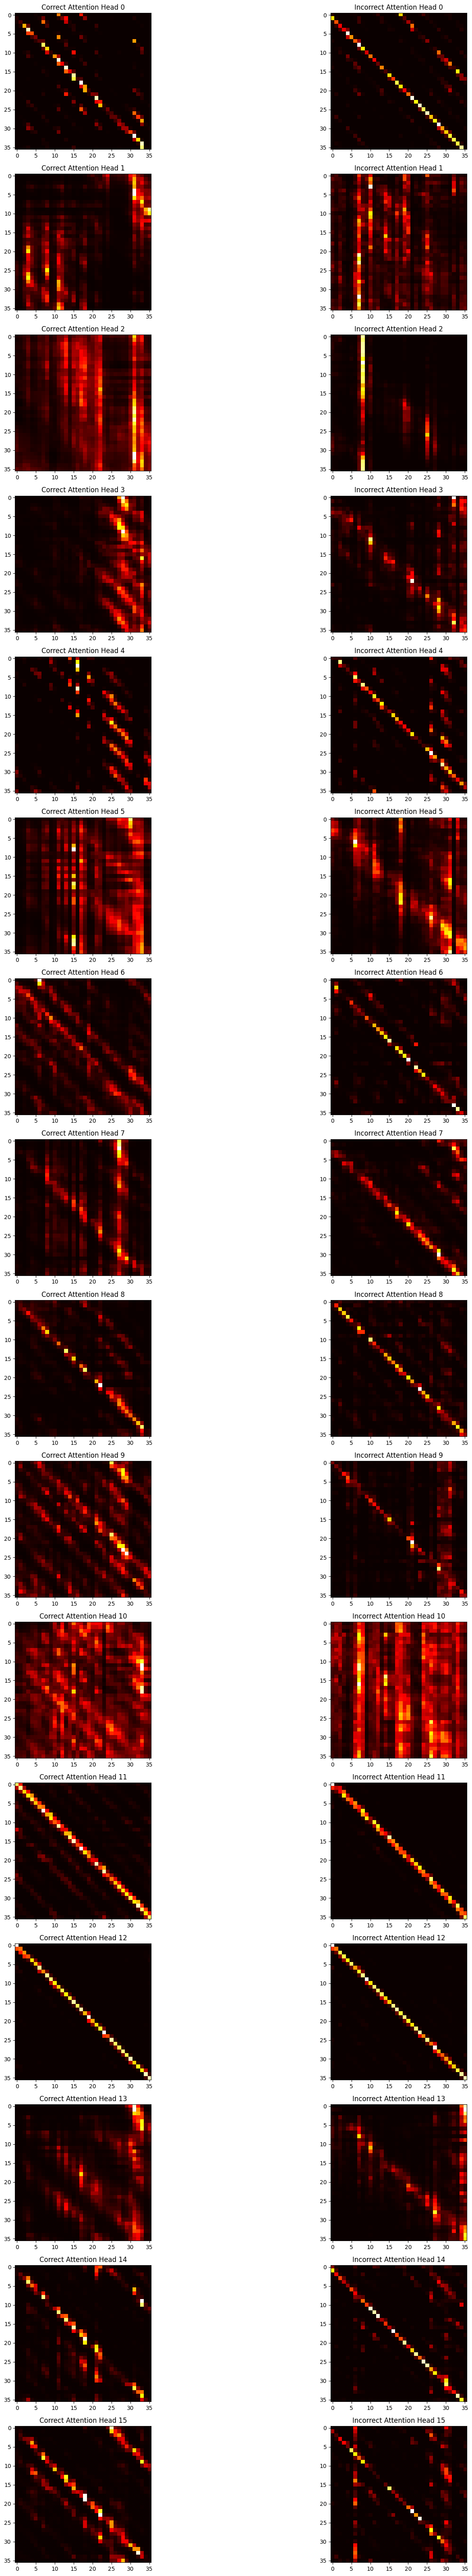

In [ ]:

plot_attention_heads(attention_for_correct_example, attention_for_incorrect_example)

Generating predictions for confusion matrix...
Processed batch 0/313
Processed batch 10/313
Processed batch 20/313
Processed batch 30/313
Processed batch 40/313
Processed batch 50/313
Processed batch 60/313
Processed batch 70/313
Processed batch 80/313
Processed batch 90/313
Processed batch 100/313
Processed batch 110/313
Processed batch 120/313
Processed batch 130/313
Processed batch 140/313
Processed batch 150/313
Processed batch 160/313
Processed batch 170/313
Processed batch 180/313
Processed batch 190/313
Processed batch 200/313
Processed batch 210/313
Processed batch 220/313
Processed batch 230/313
Processed batch 240/313
Processed batch 250/313
Processed batch 260/313
Processed batch 270/313
Processed batch 280/313
Processed batch 290/313
Processed batch 300/313
Processed batch 310/313


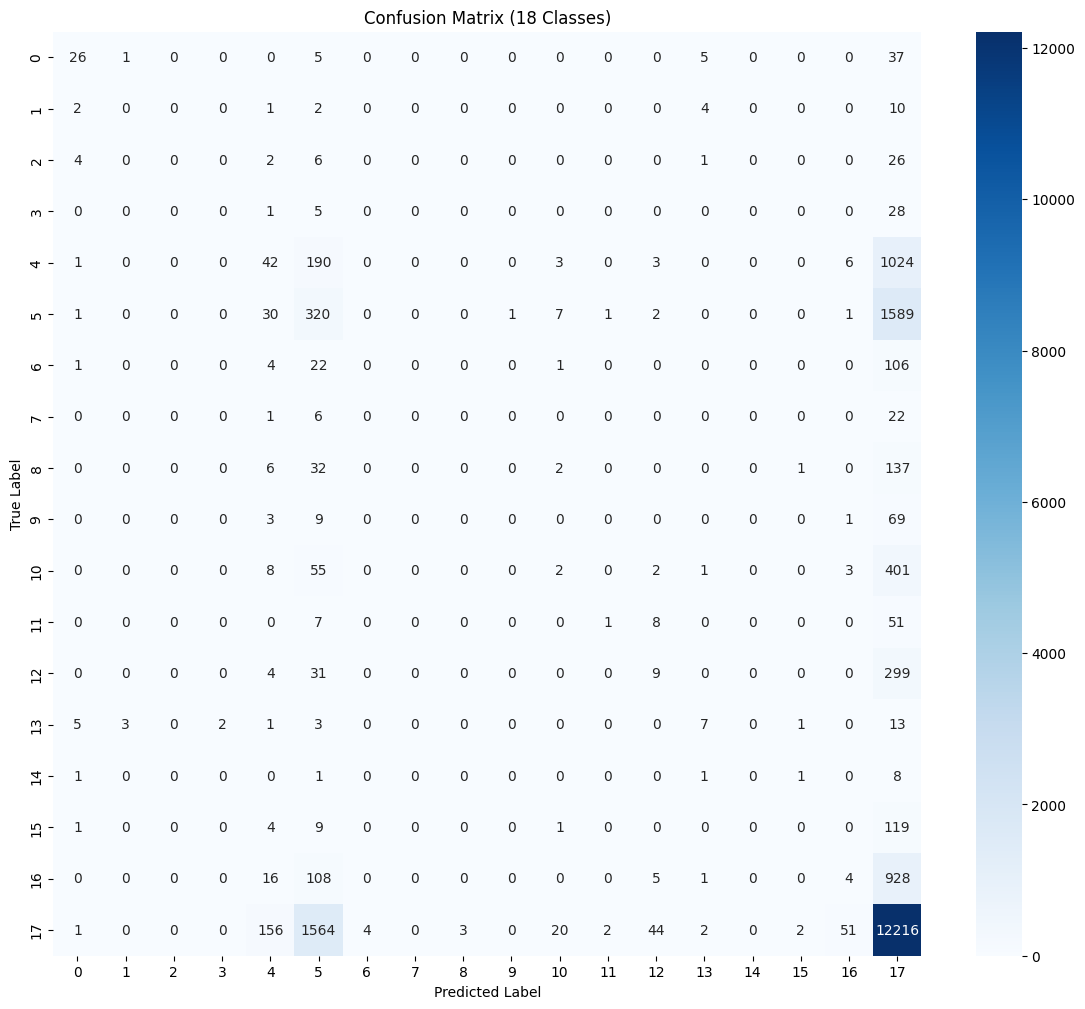


Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.35      0.44        74
           1       0.00      0.00      0.00        19
           2       0.00      0.00      0.00        39
           3       0.00      0.00      0.00        34
           4       0.15      0.03      0.05      1269
           5       0.13      0.16      0.15      1952
           6       0.00      0.00      0.00       134
           7       0.00      0.00      0.00        29
           8       0.00      0.00      0.00       178
           9       0.00      0.00      0.00        82
          10       0.06      0.00      0.01       472
          11       0.25      0.01      0.03        67
          12       0.12      0.03      0.04       343
          13       0.32      0.20      0.25        35
          14       0.00      0.00      0.00        12
          15       0.00      0.00      0.00       134
          16       0.06      0.00      0.01      1062
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
all_preds = []
all_labels = []

model.eval()
print("Generating predictions for confusion matrix...")
with torch.no_grad():
    for i, batch in enumerate(test_dataloader):
        sequences, labels = batch
        tokens = tokenizer(list(sequences), padding=True, truncation=True, return_tensors="pt")
        tokens = {k: v.to(DEVICE) for k, v in tokens.items()}
        labels = labels.to(DEVICE)

        outputs = model(**tokens)
        _, predicted = torch.max(outputs.logits, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if i % 10 == 0:
             print(f"Processed batch {i}/{len(test_dataloader)}")

# Plot Confusion Matrix
plt.figure(figsize=(14, 12))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (18 Classes)')
plt.show()

# Print Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

In [ ]:
# Test the tokenizer's behavior regarding special tokens
sample_seq = "ACGT"

# Default behavior (add_special_tokens=True by default)
tokens_default = tokenizer(sample_seq)
print(f"Input IDs (default): {tokens_default['input_ids']}")
print(f"Tokens (default): {tokenizer.convert_ids_to_tokens(tokens_default['input_ids'])}")

# Without special tokens
tokens_no_special = tokenizer(sample_seq, add_special_tokens=False)
print(f"Input IDs (no special): {tokens_no_special['input_ids']}")
print(f"Tokens (no special): {tokenizer.convert_ids_to_tokens(tokens_no_special['input_ids'])}")

# Check what the CLS token is for this specific model
print(f"CLS token: {tokenizer.cls_token}")
print(f"CLS token ID: {tokenizer.cls_token_id}")

print(type(model))

Input IDs (default): [3, 4102, 4104, 4105, 4103]
Tokens (default): ['<cls>', 'A', 'C', 'G', 'T']
Input IDs (no special): [4102, 4104, 4105, 4103]
Tokens (no special): ['A', 'C', 'G', 'T']
CLS token: <cls>
CLS token ID: 3
<class 'transformers_modules.InstaDeepAI.nucleotide-transformer-v2-500m-multi-species.06615c1660c892fc199840c18123f8385b3542a8.modeling_esm.EsmForSequenceClassification'>
